In [1]:
import sys
import os
import numpy as np

from scipy.integrate import cumulative_trapezoid

sys.path.append(os.path.join(os.getcwd(), ".."))
from models.MPC import *

In [2]:
N_EXP = 4 #number of experiments to be used in the BO iteration
horizon = 10
dt = 3
t_step = 300

min_max_dict = {
    "u_min": 0.0,
    "u_max": 36.0,
    "x_min": 0.0,
    "x_max": 8.5,
    "y_min": 0.0,
    "y_max": 8.5
}

mpc_bounds_debug = {
    "u_min": 0.0,
    "u_max": 36.0,
    "x_min": 0.0,
    "x_max": 8.5,
}

In [3]:
X0 = np.asarray([[0.5], 
                [0.5]])
X0_init_guess = np.clip(X0 + np.random.rand(X0.shape[0], X0.shape[1]) - 0.5, 0.0, 8.5)

In [4]:
system = environment()

In [5]:
def eval_Q(X0, X0_init_guess, Q_guess, traj=False):
    score = 0.0
    set_point = 4.5

    measurement_covar = np.array([[0.246**2]])

    mpc_bounds = {
        "u_min": 0.0,
        "u_max": 36.0,
        # Temporarily remove x/y hard constraints for feasibility debugging
         "x_min": 0.0,
         "x_max": 8.5,
         "y_min": 0.0,
         "y_max": 8.5,
    }

    if traj:
        x_pred_traj = []
        x_true_traj = []
        input_traj = []

    for i in range(X0.shape[1]):

        xk = X0[:, [i]]
        xk = np.clip(xk, 0.0, 8.5)

        x0_est = X0_init_guess[:, [i]]
        x0_est = np.clip(x0_est, 0.0, 8.5)

        controller = ModelPredictiveControl(
            x0_est,
            measurement_covar=measurement_covar,
            A=system.Ad,
            B=system.Bd,
            C=system.C,
            Q=Q_guess,
            R=np.array([[1]]),
            N=horizon,
            set_point=set_point,
            state_noise_covar=np.array([[1, 2e-1], [2e-1, 1]]),
            estim_err_covar=None,
        )

        x2_error_traj = []

        if traj:
            x_pred = []
            x_true = []
            input_seq = []

        for j in range(t_step):

            uk, _, _ = controller.control(
                dt=dt,
                **mpc_bounds,
            )

            uk = np.asarray([[uk]], dtype=float)

            x_k1, y_k = system.step(xk, uk, dt=dt)

            x_k1 = np.asarray(x_k1, dtype=float).reshape(system.nx, 1)
            y_k = np.asarray(y_k, dtype=float).reshape(system.ny, 1)

            controller.update_state(y_k, uk)

            x2 = float(x_k1[1, 0])
            x2_error_traj.append((x2 - set_point) ** 2)

            xk = x_k1

            if traj:
                x_pred.append(np.asarray(controller.state, dtype=float).reshape(system.nx, 1))
                x_true.append(xk.copy())
                input_seq.append(uk.copy())

        experiment_score = cumulative_trapezoid(
            y=x2_error_traj,
            dx=dt,
            initial=0.0,
        )[-1]

        score += experiment_score

        if traj:
            x_pred_traj.append(x_pred)
            x_true_traj.append(x_true)
            input_traj.append(input_seq)

    score = score / X0.shape[1]

    if traj:
        return float(score), {
            "x_pred_traj": x_pred_traj,
            "x_true_traj": x_true_traj,
            "input_traj": input_traj,
        }

    return float(score)

In [6]:
def build_Q_from_theta(theta):
    theta = np.asarray(theta, dtype=float).reshape(-1)

    q_y = 10.0 ** theta[0]

    Q = np.array([[q_y]])

    return Q

def bo_objective(theta):
    """
    theta is log10-scale Q parameter.

    Example:
        theta = [2, 3]
        Q = diag([100, 1000])
    """

    Q_candidate = build_Q_from_theta(theta)

    try:
        loss = eval_Q(
            X0=X0,
            X0_init_guess=X0_init_guess,
            Q_guess=Q_candidate,
            traj=False,
        )

        if not np.isfinite(loss):
            loss = 1e12

    except Exception as e:
        print("Evaluation failed.")
        print("theta:", theta)
        print("Q:", Q_candidate)
        print("Error:", e)

        loss = 1e12

    objective_value = -loss

    return objective_value

In [7]:
import torch

from botorch.models import SingleTaskGP
from botorch.models.transforms import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement
from botorch.optim import optimize_acqf

from gpytorch.mlls import ExactMarginalLogLikelihood

In [8]:
def run_bo_for_Q(
    n_init=5,
    n_iter=20,
    q_log_lower=-2,
    q_log_upper=6,
    seed=0,
):
    """
    Bayesian optimization for diagonal Q matrix.

    Search variable:
        theta = [log10(q1), log10(q2)]

    Q:
        Q = diag([10^theta1, 10^theta2])

    Parameters
    ----------
    n_init : int
        Number of initial random evaluations.

    n_iter : int
        Number of BO iterations.

    q_log_lower : float
        Lower bound of log10(q).

    q_log_upper : float
        Upper bound of log10(q).

    seed : int
        Random seed.

    Returns
    -------
    best_Q : np.ndarray
        Best Q matrix found.

    best_loss : float
        Best loss found.

    history : dict
        BO search history.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    dtype = torch.double
    device = torch.device("cpu")

    dim = 1

    bounds = torch.tensor(
        [
            [q_log_lower],
            [q_log_upper],
        ],
        dtype=dtype,
        device=device,
    )

    train_X_list = []
    train_Y_list = []

    history = {
        "theta": [],
        "Q": [],
        "loss": [],
        "objective": [],
    }

    # Initial random samples in log-space
    for k in range(n_init):

        theta = q_log_lower + (q_log_upper - q_log_lower) * np.random.rand(dim)

        objective_value = bo_objective(theta)
        loss = -objective_value

        Q_candidate = build_Q_from_theta(theta)

        train_X_list.append(theta)
        train_Y_list.append([objective_value])

        history["theta"].append(theta.copy())
        history["Q"].append(Q_candidate.copy())
        history["loss"].append(loss)
        history["objective"].append(objective_value)

        print(f"[Init {k + 1}/{n_init}]")
        print("theta:", theta)
        print("Q:")
        print(Q_candidate)
        print("loss:", loss)
        print("-" * 50)

    train_X = torch.tensor(np.array(train_X_list), dtype=dtype, device=device)
    train_Y = torch.tensor(np.array(train_Y_list), dtype=dtype, device=device)

    for it in range(n_iter):

        model = SingleTaskGP(
            train_X,
            train_Y,
            outcome_transform=Standardize(m=1),
        )

        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        best_f = train_Y.max()

        acquisition_function = LogExpectedImprovement(
            model=model,
            best_f=best_f,
        )

        candidate, acq_value = optimize_acqf(
            acq_function=acquisition_function,
            bounds=bounds,
            q=1,
            num_restarts=10,
            raw_samples=128,
        )

        theta_next = candidate.detach().cpu().numpy().reshape(-1)

        objective_value = bo_objective(theta_next)
        loss = -objective_value

        Q_candidate = build_Q_from_theta(theta_next)

        new_X = torch.tensor(
            theta_next.reshape(1, -1),
            dtype=dtype,
            device=device,
        )

        new_Y = torch.tensor(
            [[objective_value]],
            dtype=dtype,
            device=device,
        )

        train_X = torch.cat([train_X, new_X], dim=0)
        train_Y = torch.cat([train_Y, new_Y], dim=0)

        history["theta"].append(theta_next.copy())
        history["Q"].append(Q_candidate.copy())
        history["loss"].append(loss)
        history["objective"].append(objective_value)

        best_idx = int(np.argmin(history["loss"]))

        print(f"[BO Iter {it + 1}/{n_iter}]")
        print("theta_next:", theta_next)
        print("Q_next:")
        print(Q_candidate)
        print("loss:", loss)
        print("current best loss:", history["loss"][best_idx])
        print("current best Q:")
        print(history["Q"][best_idx])
        print("-" * 50)

    best_idx = int(np.argmin(history["loss"]))

    best_Q = history["Q"][best_idx]
    best_loss = history["loss"][best_idx]

    return best_Q, best_loss, history

In [9]:
best_Q, best_loss, history = run_bo_for_Q(
    n_init=5,
    n_iter=20,
    q_log_lower=-2,
    q_log_upper=6,
    seed=0,
)

print("Best Q:")
print(best_Q)

print("Best loss:")
print(best_loss)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

[Init 1/5]
theta: [2.39050803]
Q:
[[245.75820789]]
loss: 1011.9047489737063
--------------------------------------------------
[Init 2/5]
theta: [3.72151493]
Q:
[[5266.41320433]]
loss: 697.6177785713144
--------------------------------------------------
[Init 3/5]
theta: [2.82210701]
Q:
[[663.90663442]]
loss: 736.1175095792444
--------------------------------------------------
[Init 4/5]
theta: [2.35906546]
Q:
[[228.59433522]]
loss: 1035.9672687090222
--------------------------------------------------
[Init 5/5]
theta: [1.38923839]
Q:
[[24.50407961]]
loss: 1576.7537709694614
-------------------------------

c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


[BO Iter 1/20]
theta_next: [3.29977401]
Q_next:
[[1994.22431351]]
loss: 696.4390364751199
current best loss: 696.4390364751199
current best Q:
[[1994.22431351]]
--------------------------------------------------


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


[BO Iter 2/20]
theta_next: [4.76962972]
Q_next:
[[58834.18141326]]
loss: 705.1960626657002
current best loss: 696.4390364751199
current best Q:
[[1994.22431351]]
--------------------------------------------------


...

[BO Iter 18/20]
theta_next: [3.87571373]
Q_next:
[[7511.27608205]]
loss: 698.8423026372118
current best loss: 695.9227459605977
current best Q:
[[2504.51358926]]
--------------------------------------------------


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


[BO Iter 19/20]
theta_next: [3.19890637]
Q_next:
[[1580.90718683]]
loss: 698.7039203493936
current best loss: 695.9227459605977
current best Q:
[[2504.51358926]]
--------------------------------------------------


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\optim\optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


[BO Iter 20/20]
theta_next: [3.82293702]
Q_next:
[[6651.76683717]]
loss: 698.3193930176134
current best loss: 695.9227459605977
current best Q:
[[2504.51358926]]
--------------------------------------------------
Best Q:
[[2504.51358926]]
Best loss:
695.9227459605977


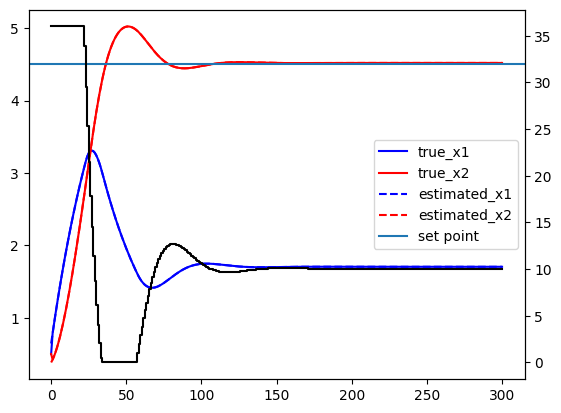

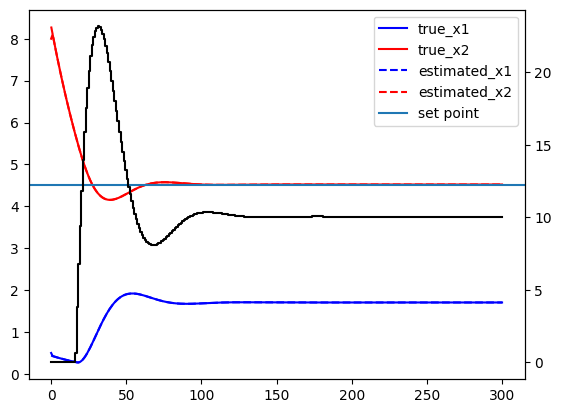

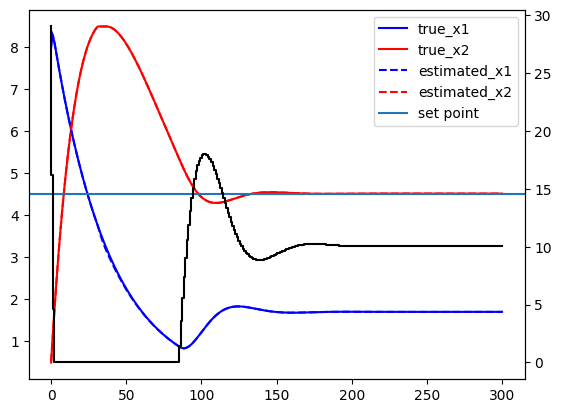

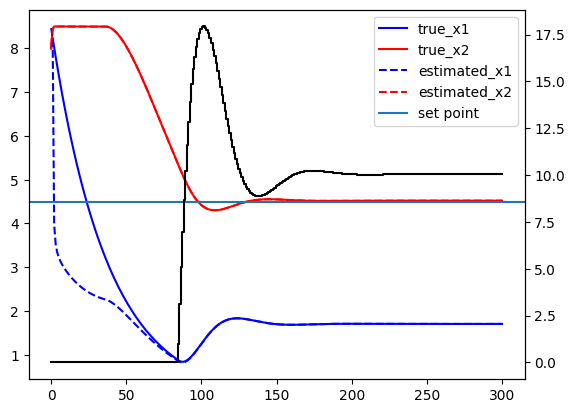

In [10]:
import matplotlib.pyplot as plt

X0 = np.asarray([[0.5, 0.5, 8.0, 8.0], 
                [0.5, 8.0, 0.5, 8.0]])
X0_init_guess = np.clip(X0 + np.random.rand(X0.shape[0], X0.shape[1]) - 0.5, 0.0, 8.5)

mpc_bounds = {
    "u_min": 0.0,
    "u_max": 36.0
}

for i in range(X0.shape[1]):
    true_state = X0[:,[i]]
    estimated_state = X0_init_guess[:,[i]]
    input = []

    controller = ModelPredictiveControl(
        init_guess=X0_init_guess[:, [i]],
        measurement_covar=np.array([[0.246**2]]),
        A=system.Ad,
        B=system.Bd,
        C=system.C,
        Q=best_Q,
        R=np.array([[1]]),
        N=10,
        set_point=4.5,
        state_noise_covar=np.array([[1, 2e-1], [2e-1, 1]]),
        estim_err_covar=None,
    )
    xk = estimated_state
    for j in range(t_step):
        uk, _, _ = controller.control(
            dt=dt,
            **mpc_bounds,
        )
        input.append(uk)

        x_k1, y_k = system.step(xk, uk, dt=dt)

        x_k1 = np.asarray(x_k1, dtype=float).reshape(system.nx, 1)
        y_k = np.asarray(y_k, dtype=float).reshape(system.ny, 1)

        controller.update_state(y_k, uk)
        xk = x_k1

        true_state = np.hstack((true_state, xk))
        estimated_state = np.hstack((estimated_state, controller.state))

    fig, ax1 = plt.subplots()
    ax1.plot(true_state[0,:], c="b", label="true_x1")
    ax1.plot(true_state[1,:], c="r", label="true_x2")
    ax1.plot(estimated_state[0,:], c="b", ls="--", label="estimated_x1")
    ax1.plot(estimated_state[1,:], c="r", ls="--", label="estimated_x2")
    ax1.axhline(4.5, label="set point")
    plt.legend()
    ax2 = ax1.twinx()
    plt.step(np.linspace(0,300,300), input, c="k", label="input")
    plt.show()